# Ejercicios de Distribuciones Continuas

Ejercicios resueltos de distribuciones de probabilidad continuas: Normal, Exponencial, t-Student, Chi-cuadrado y F de Snedecor.

In [1]:
from IPython.display import display, HTML
display(HTML("""<style>
.colab-df-container { max-width: 100% !important; }
div.output_area pre { white-space: pre-wrap; }
.rendered_html table { width: 100% !important; }
.rendered_html { font-size: 15px; line-height: 1.6; }
div.text_cell_render { max-width: none !important; padding: 0 20px; }
</style>"""))

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Paleta de colores
C_PRIMARY = '#3498db'
C_DANGER = '#e74c3c'
C_SUCCESS = '#2ecc71'
C_DARK = '#2c3e50'
C_ORANGE = '#f39c12'

# Estilo global
plt.rcParams.update({
    'figure.figsize': (10, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

## Indice de ejercicios

| N | Distribucion | Enunciado |
|---|---|---|
| 1 | Normal | Probabilidad de que una altura este entre 160 y 180 cm, con N(170, 10) |
| 2 | Normal | Calificacion minima para estar en el top 5%, con N(65, 12) |
| 3 | Exponencial | Probabilidad de que un componente dure mas de 600 horas, con Exp(1/500) |
| 4 | t-Student | Intervalo de confianza al 95% para la media con n=15, media=72, s=8 |
| 5 | Chi-cuadrado | Contraste de hipotesis sobre la varianza con n=20, s2=25, sigma0_2=20 |
| 6 | Normal | Valores criticos z para niveles de confianza 0.90, 0.95 y 0.99 |
| 7 | F-Snedecor | Comparar variabilidad de dos procesos con s1_2=15, n1=25, s2_2=10, n2=30 |
| 8 | Todas | Galeria visual de distribuciones continuas con diferentes parametros |
| 9 | Normal | IQ sigue N(100, 15). Porcentaje con IQ entre 85 y 115, y por encima de 130 |
| 10 | Exponencial | Tiempo entre llamadas Exp(lambda=3). Probabilidad de esperar mas de 1 minuto |
| 11 | Gamma | Tiempo para 5 eventos con tasa 2/hora, Gamma(5, 2). Calcular E[T] y P(T>4) |
| 12 | Beta | Proporcion de exitos Beta(2, 5). Calcular E[X], moda y graficar |
| 13 | Chi-cuadrado | Suma de 10 normales estandar al cuadrado, Chi2(10). Calcular P(chi2 > 18.31) |
| 14 | t-Student | Muestra n=8, media=25, s=4. Probabilidad de que t > 2.0 con 7 gl |
| 15 | Log-normal | Salarios LogN(mu=10, sigma=0.5). Mediana, media y P(salario > 30000) |
| 16 | Uniforme continua | Tiempo de espera U(0, 10). P(entre 3 y 7) y E[X] |
| 17 | Normal | Regla 68-95-99.7: verificar con simulacion de 100000 muestras N(0,1) |
| 18 | Exponencial | Propiedad sin memoria: P(X>s+t dado X>s) = P(X>t). Demostrar y simular |
| 19 | F-Snedecor | Cociente de dos Chi2 independientes divididas por sus gl. Simular y comparar con F teorica |
| 20 | Todas | Galeria visual: graficar 9 distribuciones continuas en un grid 3x3 |

## Formulas de distribuciones continuas

---

### 1. Normal — $X \sim N(\mu, \sigma)$

**PDF (funcion de densidad de probabilidad):**

$$f(x) = \frac{1}{\sigma\sqrt{2\pi}} \, e^{-\frac{(x-\mu)^2}{2\sigma^2}}, \quad x \in (-\infty, \infty)$$

- $\mu$: media (centro de la campana)
- $\sigma$: desviacion estandar (controla el ancho de la campana)
- $\sigma^2$: varianza
- $e$: constante de Euler (aprox. 2.71828)
- $\pi$: constante pi (aprox. 3.14159)

**Esperanza:** $E[X] = \mu$

**Varianza:** $\text{Var}(X) = \sigma^2$

---

### 2. Exponencial — $X \sim \text{Exp}(\lambda)$

**PDF:**

$$f(x) = \lambda \, e^{-\lambda x}, \quad x \geq 0$$

- $\lambda$: tasa del evento (numero medio de eventos por unidad de tiempo)
- $1/\lambda$: tiempo medio entre eventos

**Esperanza:** $E[X] = \frac{1}{\lambda}$

**Varianza:** $\text{Var}(X) = \frac{1}{\lambda^2}$

---

### 3. Gamma — $X \sim \text{Gamma}(\alpha, \beta)$

**PDF:**

$$f(x) = \frac{\beta^\alpha}{\Gamma(\alpha)} \, x^{\alpha-1} \, e^{-\beta x}, \quad x > 0$$

- $\alpha$ (shape): parametro de forma, indica el numero de eventos acumulados
- $\beta$ (rate): parametro de tasa, inverso de la escala
- $\Gamma(\alpha)$: funcion Gamma, generalizacion del factorial; $\Gamma(n) = (n-1)!$ para enteros positivos

**Esperanza:** $E[X] = \frac{\alpha}{\beta}$

**Varianza:** $\text{Var}(X) = \frac{\alpha}{\beta^2}$

---

### 4. Beta — $X \sim \text{Beta}(\alpha, \beta)$

**PDF:**

$$f(x) = \frac{x^{\alpha-1}(1-x)^{\beta-1}}{B(\alpha, \beta)}, \quad x \in [0, 1]$$

- $\alpha$: parametro de forma asociado a exitos
- $\beta$: parametro de forma asociado a fracasos
- $B(\alpha, \beta)$: funcion Beta, $B(\alpha, \beta) = \frac{\Gamma(\alpha)\Gamma(\beta)}{\Gamma(\alpha+\beta)}$

**Esperanza:** $E[X] = \frac{\alpha}{\alpha + \beta}$

**Varianza:** $\text{Var}(X) = \frac{\alpha\beta}{(\alpha+\beta)^2(\alpha+\beta+1)}$

---

### 5. t-Student — $T \sim t(\nu)$

**PDF:**

$$f(t) = \frac{\Gamma\left(\frac{\nu+1}{2}\right)}{\sqrt{\nu\pi}\;\Gamma\left(\frac{\nu}{2}\right)} \left(1 + \frac{t^2}{\nu}\right)^{-\frac{\nu+1}{2}}, \quad t \in (-\infty, \infty)$$

- $\nu$ (nu): grados de libertad, tipicamente $n - 1$ donde $n$ es el tamano muestral
- $\Gamma$: funcion Gamma

**Esperanza:** $E[T] = 0$ (para $\nu > 1$)

**Varianza:** $\text{Var}(T) = \frac{\nu}{\nu - 2}$ (para $\nu > 2$)

---

### 6. Chi-cuadrado — $X \sim \chi^2(k)$

**PDF:**

$$f(x) = \frac{1}{2^{k/2}\,\Gamma(k/2)} \, x^{k/2 - 1} \, e^{-x/2}, \quad x > 0$$

- $k$: grados de libertad (numero de normales estandar al cuadrado sumadas)
- $\Gamma$: funcion Gamma

**Esperanza:** $E[X] = k$

**Varianza:** $\text{Var}(X) = 2k$

---

### 7. F de Snedecor — $X \sim F(d_1, d_2)$

**PDF:**

$$f(x) = \frac{\sqrt{\frac{(d_1 x)^{d_1} \cdot d_2^{d_2}}{(d_1 x + d_2)^{d_1+d_2}}}}{x\,B\left(\frac{d_1}{2}, \frac{d_2}{2}\right)}, \quad x > 0$$

- $d_1$: grados de libertad del numerador
- $d_2$: grados de libertad del denominador
- $B$: funcion Beta

**Esperanza:** $E[X] = \frac{d_2}{d_2 - 2}$ (para $d_2 > 2$)

**Varianza:** $\text{Var}(X) = \frac{2\,d_2^2\,(d_1 + d_2 - 2)}{d_1\,(d_2-2)^2\,(d_2-4)}$ (para $d_2 > 4$)

---

### 8. Uniforme continua — $X \sim U(a, b)$

**PDF:**

$$f(x) = \frac{1}{b - a}, \quad x \in [a, b]$$

- $a$: limite inferior del intervalo
- $b$: limite superior del intervalo
- La densidad es constante en todo el intervalo

**Esperanza:** $E[X] = \frac{a + b}{2}$

**Varianza:** $\text{Var}(X) = \frac{(b - a)^2}{12}$

---

### 9. Log-normal — $X \sim \text{LogN}(\mu, \sigma)$

**PDF:**

$$f(x) = \frac{1}{x\,\sigma\sqrt{2\pi}} \, e^{-\frac{(\ln x - \mu)^2}{2\sigma^2}}, \quad x > 0$$

- $\mu$: media del logaritmo natural de $X$ (no la media de $X$ en si)
- $\sigma$: desviacion estandar del logaritmo natural de $X$
- $\ln x$: logaritmo natural de $x$
- Si $Y \sim N(\mu, \sigma)$, entonces $X = e^Y \sim \text{LogN}(\mu, \sigma)$

**Esperanza:** $E[X] = e^{\mu + \sigma^2/2}$

**Varianza:** $\text{Var}(X) = \left(e^{\sigma^2} - 1\right) e^{2\mu + \sigma^2}$

**Ejercicio 1:** Las alturas de una poblacion siguen una distribucion Normal con media 170 cm y desviacion estandar 10 cm. Cual es la probabilidad de que una persona elegida al azar mida entre 160 y 180 cm?

**Resolucion:**

La variable X = "altura" sigue una distribucion **Normal** con parametros:
- **mu = 170** (media poblacional)
- **sigma = 10** (desviacion estandar)

**Formula de estandarizacion:** $Z = \frac{X - \mu}{\sigma}$

**Calculo paso a paso:**

$$P(160 < X < 180) = P\left(\frac{160-170}{10} < Z < \frac{180-170}{10}\right) = P(-1 < Z < 1)$$

$$= \Phi(1) - \Phi(-1) = 0.8413 - 0.1587 = 0.6827$$

Este resultado corresponde a la conocida regla del 68-95-99.7: aproximadamente el 68.27% de los datos caen dentro de una desviacion estandar de la media.

Z1 = (160 - 170) / 10 = -1.0
Z2 = (180 - 170) / 10 = 1.0
P(160 < X < 180) = Phi(1.0) - Phi(-1.0) = 0.8413 - 0.1587 = 0.6827


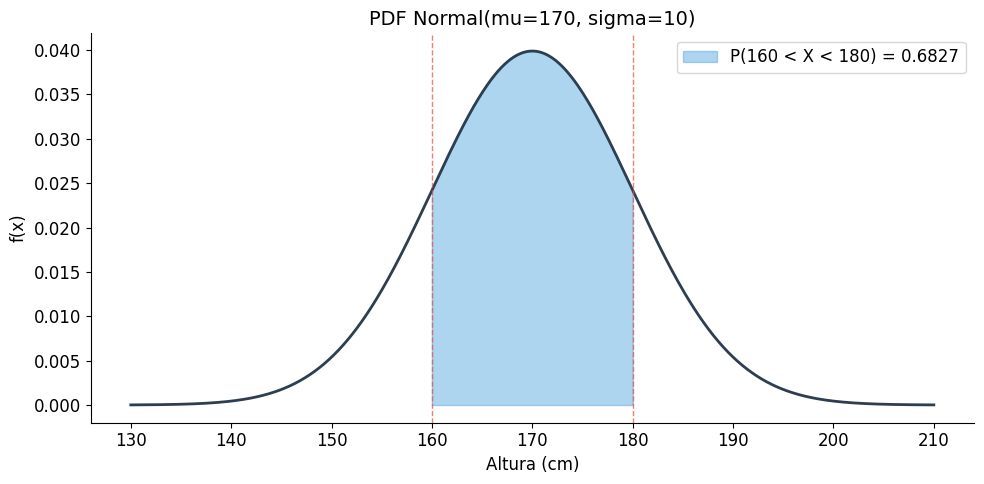

In [2]:
mu, sigma = 170, 10
X = stats.norm(mu, sigma)

prob = X.cdf(180) - X.cdf(160)
z1 = (160 - mu) / sigma
z2 = (180 - mu) / sigma
print(f"Z1 = (160 - {mu}) / {sigma} = {z1}")
print(f"Z2 = (180 - {mu}) / {sigma} = {z2}")
print(f"P(160 < X < 180) = Phi({z2}) - Phi({z1}) = {X.cdf(180):.4f} - {X.cdf(160):.4f} = {prob:.4f}")

# Grafica con area sombreada
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 500)
pdf = X.pdf(x)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, pdf, color=C_DARK, linewidth=2)

# Area sombreada entre 160 y 180
x_fill = np.linspace(160, 180, 300)
ax.fill_between(x_fill, X.pdf(x_fill), alpha=0.4, color=C_PRIMARY, label=f'P(160 < X < 180) = {prob:.4f}')

ax.axvline(x=160, color=C_DANGER, linestyle='--', linewidth=1, alpha=0.7)
ax.axvline(x=180, color=C_DANGER, linestyle='--', linewidth=1, alpha=0.7)
ax.set_xlabel('Altura (cm)')
ax.set_ylabel('f(x)')
ax.set_title(f'PDF Normal(mu={mu}, sigma={sigma})')
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

**Ejercicio 2:** En un examen, las calificaciones siguen una distribucion Normal con media 65 y desviacion estandar 12. Que nota necesitas para estar en el top 5% de la clase?

**Resolucion:**

La variable X = "calificacion" sigue $X \sim N(\mu=65, \sigma=12)$.

Queremos encontrar $x$ tal que $P(X > x) = 0.05$, es decir, $P(X \leq x) = 0.95$.

**Formula:** $x = \mu + Z_{0.95} \cdot \sigma$

**Calculo paso a paso:**

1. Encontrar el cuantil Z al 95%: $Z_{0.95} = 1.645$
2. Destransformar: $x = 65 + 1.645 \times 12 = 65 + 19.74 = 84.74$

Necesitas al menos un 84.74 para estar en el top 5%.

Z_0.95 = 1.6449
x = 65 + 1.6449 * 12 = 84.74
Necesitas al menos 84.74 para estar en el top 5%


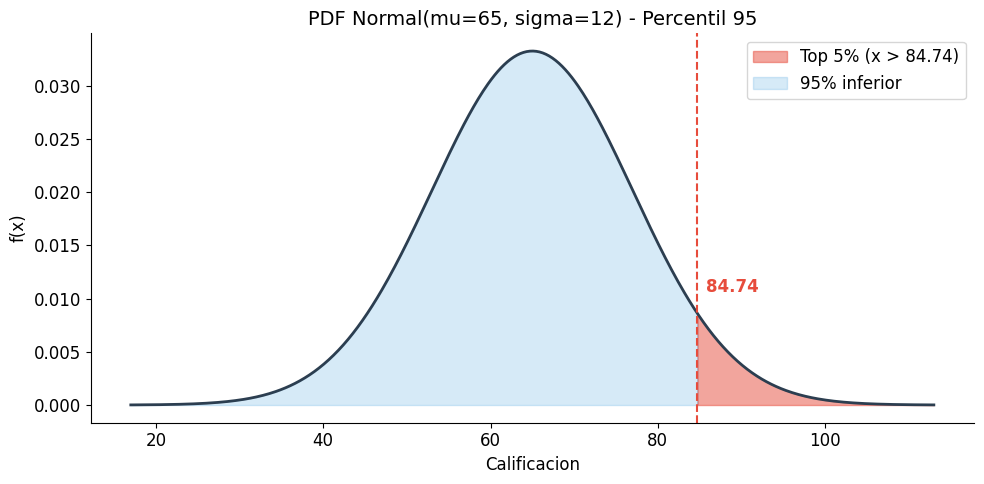

In [3]:
mu, sigma = 65, 12
X = stats.norm(mu, sigma)

z_95 = stats.norm.ppf(0.95)
x_top5 = mu + z_95 * sigma

print(f"Z_0.95 = {z_95:.4f}")
print(f"x = {mu} + {z_95:.4f} * {sigma} = {x_top5:.2f}")
print(f"Necesitas al menos {x_top5:.2f} para estar en el top 5%")

# Grafica
x_vals = np.linspace(mu - 4*sigma, mu + 4*sigma, 500)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x_vals, X.pdf(x_vals), color=C_DARK, linewidth=2)

# Area del top 5%
x_top = np.linspace(x_top5, mu + 4*sigma, 300)
ax.fill_between(x_top, X.pdf(x_top), alpha=0.5, color=C_DANGER, label=f'Top 5% (x > {x_top5:.2f})')

# Area del 95% inferior
x_bot = np.linspace(mu - 4*sigma, x_top5, 300)
ax.fill_between(x_bot, X.pdf(x_bot), alpha=0.2, color=C_PRIMARY, label=f'95% inferior')

ax.axvline(x=x_top5, color=C_DANGER, linestyle='--', linewidth=1.5)
ax.text(x_top5 + 1, X.pdf(x_top5) + 0.002, f'{x_top5:.2f}', color=C_DANGER, fontsize=12, fontweight='bold')
ax.set_xlabel('Calificacion')
ax.set_ylabel('f(x)')
ax.set_title(f'PDF Normal(mu={mu}, sigma={sigma}) - Percentil 95')
ax.legend()
plt.tight_layout()
plt.show()

**Ejercicio 3:** Un componente electronico tiene una vida media de 500 horas (lambda = 1/500). Cual es la probabilidad de que dure mas de 600 horas? Y de que dure entre 400 y 600 horas?

**Resolucion:**

La variable X = "vida util del componente" sigue una distribucion **Exponencial** con parametro:
- **lambda = 1/500 = 0.002** (tasa de fallo)
- **E[X] = 1/lambda = 500** horas (vida media)

**Formula PDF:** $f(x) = \lambda e^{-\lambda x}$ para $x \geq 0$

**Formula supervivencia:** $P(X > t) = e^{-\lambda t}$

**Calculo paso a paso:**

*Parte a: P(X > 600)*
$$P(X > 600) = e^{-\lambda \cdot 600} = e^{-600/500} = e^{-1.2} = 0.3012$$

*Parte b: P(400 < X < 600)*
$$P(400 < X < 600) = P(X > 400) - P(X > 600) = e^{-400/500} - e^{-600/500}$$
$$= e^{-0.8} - e^{-1.2} = 0.4493 - 0.3012 = 0.1481$$

a) P(X > 600) = e^(-600/500) = e^(-1.2) = 0.3012
b) P(400 < X < 600) = F(600) - F(400) = 0.6988 - 0.5507 = 0.1481


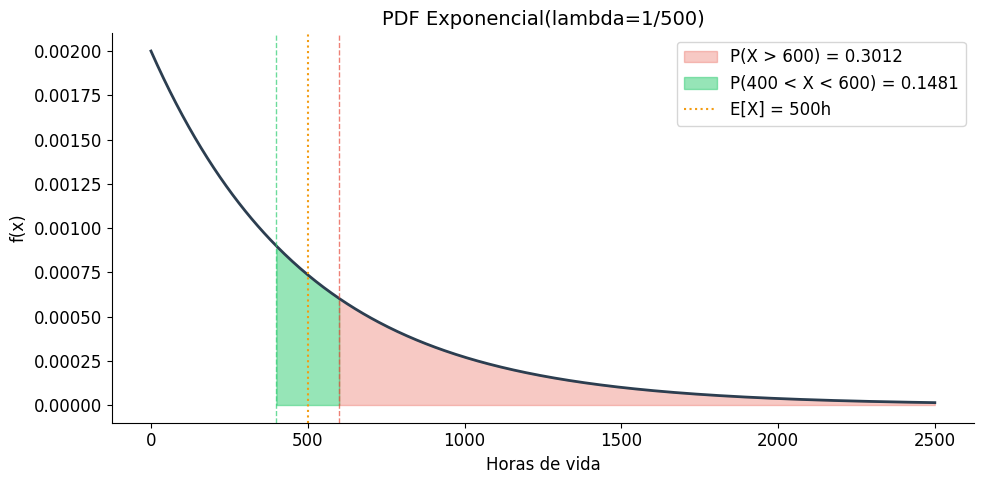

In [4]:
lam = 1/500  # tasa de fallo
# scipy expon usa scale = 1/lambda
X = stats.expon(scale=500)

prob_a = 1 - X.cdf(600)  # P(X > 600)
prob_b = X.cdf(600) - X.cdf(400)  # P(400 < X < 600)

print(f"a) P(X > 600) = e^(-600/500) = e^(-1.2) = {prob_a:.4f}")
print(f"b) P(400 < X < 600) = F(600) - F(400) = {X.cdf(600):.4f} - {X.cdf(400):.4f} = {prob_b:.4f}")

# Grafica
x_vals = np.linspace(0, 2500, 500)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x_vals, X.pdf(x_vals), color=C_DARK, linewidth=2)

# Area P(X > 600)
x_gt600 = np.linspace(600, 2500, 300)
ax.fill_between(x_gt600, X.pdf(x_gt600), alpha=0.3, color=C_DANGER, label=f'P(X > 600) = {prob_a:.4f}')

# Area P(400 < X < 600)
x_mid = np.linspace(400, 600, 300)
ax.fill_between(x_mid, X.pdf(x_mid), alpha=0.5, color=C_SUCCESS, label=f'P(400 < X < 600) = {prob_b:.4f}')

ax.axvline(x=400, color=C_SUCCESS, linestyle='--', linewidth=1, alpha=0.7)
ax.axvline(x=600, color=C_DANGER, linestyle='--', linewidth=1, alpha=0.7)
ax.axvline(x=500, color=C_ORANGE, linestyle=':', linewidth=1.5, label='E[X] = 500h')
ax.set_xlabel('Horas de vida')
ax.set_ylabel('f(x)')
ax.set_title(f'PDF Exponencial(lambda=1/500)')
ax.legend()
plt.tight_layout()
plt.show()

**Ejercicio 4:** Se toman 15 muestras de un proceso y se obtiene una media muestral de 72 y una desviacion estandar muestral de 8. Construir un intervalo de confianza al 95% para la media poblacional.

**Resolucion:**

Como sigma es desconocida y n=15 es pequeno, usamos la distribucion **t-Student** con parametros:
- **n = 15** (tamano muestral)
- **gl = n - 1 = 14** (grados de libertad)
- **x_barra = 72** (media muestral)
- **s = 8** (desviacion estandar muestral)
- **alfa = 0.05** (nivel de significacion)

**Formula del IC:** $\bar{x} \pm t_{\alpha/2, n-1} \cdot \frac{s}{\sqrt{n}}$

**Calculo paso a paso:**

1. Valor critico: $t_{0.025, 14} = 2.1448$
2. Error estandar: $\frac{s}{\sqrt{n}} = \frac{8}{\sqrt{15}} = \frac{8}{3.873} = 2.066$
3. Margen de error: $2.1448 \times 2.066 = 4.431$
4. IC: $72 \pm 4.431 = [67.57, \; 76.43]$

Grados de libertad: 14
t_critico(0.025, 14) = 2.1448
Error estandar: s/sqrt(n) = 8/sqrt(15) = 2.0656
Margen de error: 2.1448 * 2.0656 = 4.4303
IC al 95%: [67.57, 76.43]


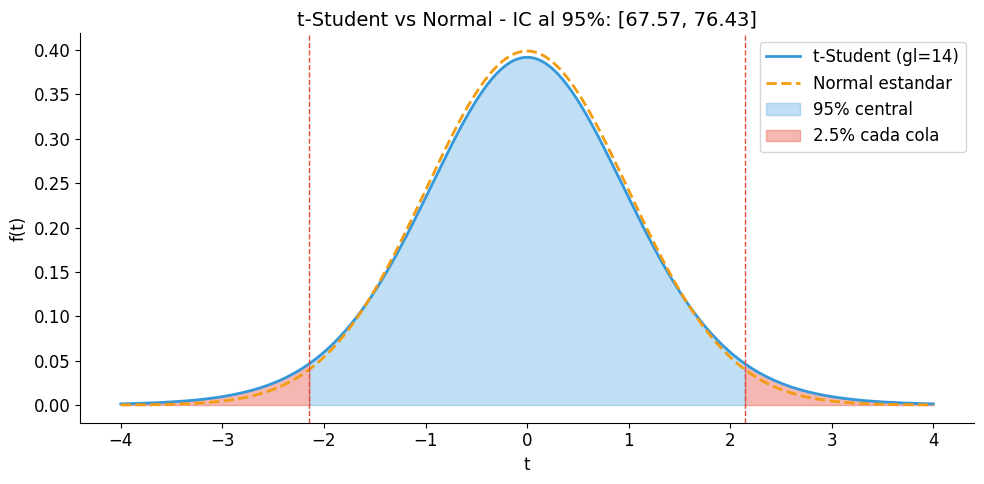

In [5]:
n, x_bar, s = 15, 72, 8
gl = n - 1
alfa = 0.05

t_crit = stats.t.ppf(1 - alfa/2, gl)
se = s / np.sqrt(n)
margen = t_crit * se
ic_inf, ic_sup = x_bar - margen, x_bar + margen

print(f"Grados de libertad: {gl}")
print(f"t_critico(0.025, {gl}) = {t_crit:.4f}")
print(f"Error estandar: s/sqrt(n) = {s}/sqrt({n}) = {se:.4f}")
print(f"Margen de error: {t_crit:.4f} * {se:.4f} = {margen:.4f}")
print(f"IC al 95%: [{ic_inf:.2f}, {ic_sup:.2f}]")

# Grafica: t-Student vs Normal estandar
x_vals = np.linspace(-4, 4, 500)
t_dist = stats.t(gl)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x_vals, t_dist.pdf(x_vals), color=C_PRIMARY, linewidth=2, label=f't-Student (gl={gl})')
ax.plot(x_vals, stats.norm.pdf(x_vals), color=C_ORANGE, linewidth=2, linestyle='--', label='Normal estandar')

# Area del IC (region central al 95%)
x_ic = np.linspace(-t_crit, t_crit, 300)
ax.fill_between(x_ic, t_dist.pdf(x_ic), alpha=0.3, color=C_PRIMARY, label=f'95% central')

# Regiones de rechazo
x_left = np.linspace(-4, -t_crit, 100)
x_right = np.linspace(t_crit, 4, 100)
ax.fill_between(x_left, t_dist.pdf(x_left), alpha=0.4, color=C_DANGER)
ax.fill_between(x_right, t_dist.pdf(x_right), alpha=0.4, color=C_DANGER, label='2.5% cada cola')

ax.axvline(x=-t_crit, color=C_DANGER, linestyle='--', linewidth=1)
ax.axvline(x=t_crit, color=C_DANGER, linestyle='--', linewidth=1)
ax.set_xlabel('t')
ax.set_ylabel('f(t)')
ax.set_title(f't-Student vs Normal - IC al 95%: [{ic_inf:.2f}, {ic_sup:.2f}]')
ax.legend()
plt.tight_layout()
plt.show()

**Ejercicio 5:** Una muestra de n=20 observaciones tiene una varianza muestral de s^2=25. Testear la hipotesis de que la varianza poblacional es sigma^2=20 con un nivel de significacion alfa=0.05 (test bilateral).

**Resolucion:**

Test de hipotesis para la varianza usando la distribucion **Chi-cuadrado**.

- **H0:** $\sigma^2 = 20$
- **H1:** $\sigma^2 \neq 20$ (bilateral)
- **n = 20**, **s^2 = 25**, **sigma_0^2 = 20**, **alfa = 0.05**

**Estadistico de prueba:** $\chi^2 = \frac{(n-1) s^2}{\sigma_0^2}$

**Calculo paso a paso:**

$$\chi^2 = \frac{(20-1) \times 25}{20} = \frac{19 \times 25}{20} = \frac{475}{20} = 23.75$$

**Valores criticos** (bilateral con gl=19):
- $\chi^2_{0.025, 19} = 32.852$ (cola superior)
- $\chi^2_{0.975, 19} = 8.907$ (cola inferior)

**Region de no rechazo:** $[8.907, \; 32.852]$

Como $23.75 \in [8.907, 32.852]$, **no se rechaza H0**. No hay evidencia suficiente para afirmar que la varianza es diferente de 20.

Estadistico chi2 = (n-1)*s2/sigma0^2 = 19*25/20 = 23.75
chi2_inf (alfa/2=0.025, gl=19) = 8.907
chi2_sup (1-alfa/2=0.975, gl=19) = 32.852
p-value = 0.4118
Decision: No rechazar H0


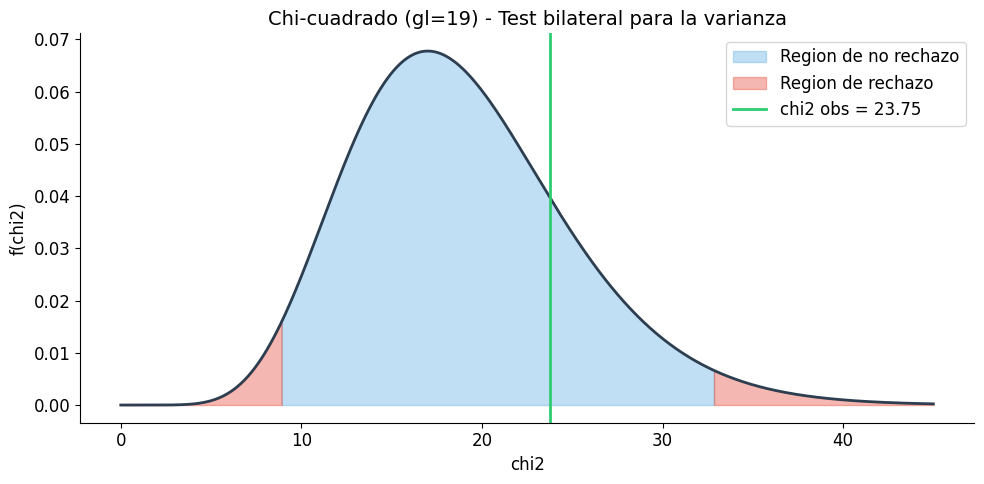

In [6]:
n, s2, sigma0_2, alfa = 20, 25, 20, 0.05
gl = n - 1

chi2_stat = (n - 1) * s2 / sigma0_2
chi2_inf = stats.chi2.ppf(alfa / 2, gl)
chi2_sup = stats.chi2.ppf(1 - alfa / 2, gl)

# p-value bilateral
p_value = 2 * min(stats.chi2.cdf(chi2_stat, gl), 1 - stats.chi2.cdf(chi2_stat, gl))

print(f"Estadistico chi2 = (n-1)*s2/sigma0^2 = {gl}*{s2}/{sigma0_2} = {chi2_stat:.2f}")
print(f"chi2_inf (alfa/2={alfa/2}, gl={gl}) = {chi2_inf:.3f}")
print(f"chi2_sup (1-alfa/2={1-alfa/2}, gl={gl}) = {chi2_sup:.3f}")
print(f"p-value = {p_value:.4f}")
print(f"Decision: {'Rechazar H0' if chi2_stat < chi2_inf or chi2_stat > chi2_sup else 'No rechazar H0'}")

# Grafica
x_vals = np.linspace(0, 45, 500)
chi2_dist = stats.chi2(gl)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x_vals, chi2_dist.pdf(x_vals), color=C_DARK, linewidth=2)

# Region de no rechazo
x_nr = np.linspace(chi2_inf, chi2_sup, 300)
ax.fill_between(x_nr, chi2_dist.pdf(x_nr), alpha=0.3, color=C_PRIMARY, label='Region de no rechazo')

# Regiones de rechazo
x_left = np.linspace(0, chi2_inf, 100)
x_right = np.linspace(chi2_sup, 45, 100)
ax.fill_between(x_left, chi2_dist.pdf(x_left), alpha=0.4, color=C_DANGER)
ax.fill_between(x_right, chi2_dist.pdf(x_right), alpha=0.4, color=C_DANGER, label='Region de rechazo')

ax.axvline(x=chi2_stat, color=C_SUCCESS, linewidth=2, linestyle='-', label=f'chi2 obs = {chi2_stat:.2f}')
ax.set_xlabel('chi2')
ax.set_ylabel('f(chi2)')
ax.set_title(f'Chi-cuadrado (gl={gl}) - Test bilateral para la varianza')
ax.legend()
plt.tight_layout()
plt.show()

**Ejercicio 6:** Calcular los valores criticos z tales que P(-z < Z < z) = 0.90, 0.95 y 0.99 para la distribucion Normal estandar. Construir una tabla de valores criticos.

**Resolucion:**

Para la distribucion **Normal estandar** $Z \sim N(0, 1)$:

Si $P(-z < Z < z) = 1 - \alpha$, entonces cada cola tiene probabilidad $\alpha/2$.

El valor critico es $z = \Phi^{-1}(1 - \alpha/2)$ donde $\Phi^{-1}$ es la funcion cuantil.

**Calculo paso a paso:**

| Confianza (1-alfa) | alfa | alfa/2 | z_critico |
|---|---|---|---|
| 0.90 | 0.10 | 0.05 | $\Phi^{-1}(0.95) = 1.6449$ |
| 0.95 | 0.05 | 0.025 | $\Phi^{-1}(0.975) = 1.9600$ |
| 0.99 | 0.01 | 0.005 | $\Phi^{-1}(0.995) = 2.5758$ |

   Confianza     alfa   alfa/2    z_critico   Verificacion P(-z<Z<z)
----------------------------------------------------------------------
        0.90     0.10    0.050       1.6449                 0.900000
        0.95     0.05    0.025       1.9600                 0.950000
        0.99     0.01    0.005       2.5758                 0.990000


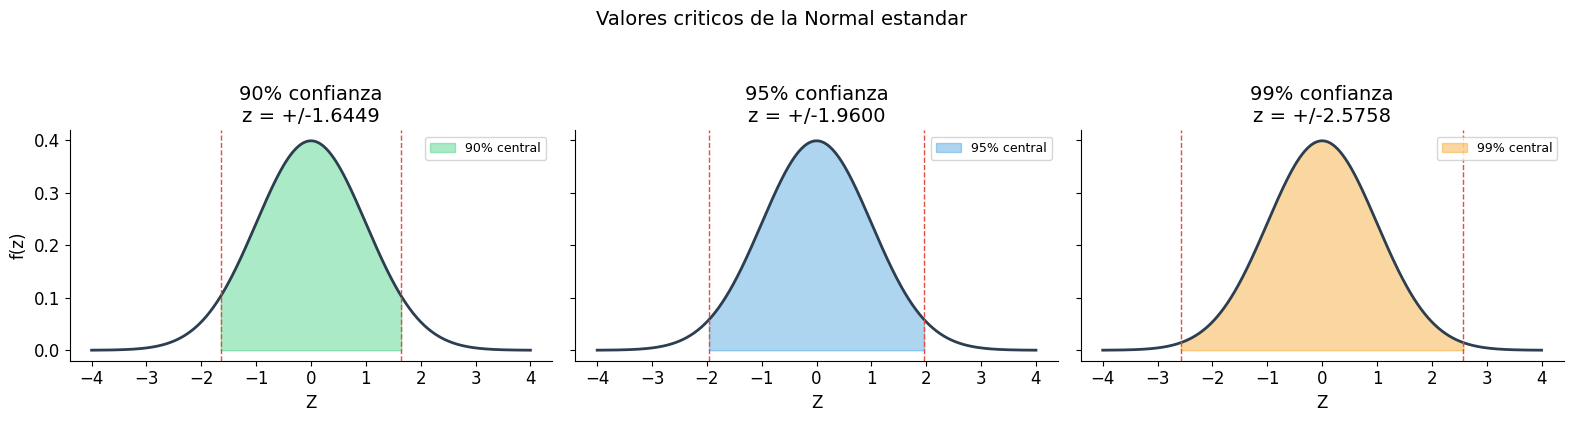

In [7]:
niveles = [0.90, 0.95, 0.99]
print(f"{'Confianza':>12} {'alfa':>8} {'alfa/2':>8} {'z_critico':>12} {'Verificacion P(-z<Z<z)':>24}")
print("-" * 70)

z_vals = []
for conf in niveles:
    alfa = 1 - conf
    z = stats.norm.ppf(1 - alfa/2)
    verif = stats.norm.cdf(z) - stats.norm.cdf(-z)
    z_vals.append(z)
    print(f"{conf:>12.2f} {alfa:>8.2f} {alfa/2:>8.3f} {z:>12.4f} {verif:>24.6f}")

# Grafica con las tres regiones sombreadas
x = np.linspace(-4, 4, 500)
Z = stats.norm(0, 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
colors_fill = [C_SUCCESS, C_PRIMARY, C_ORANGE]

for i, (conf, z, ax) in enumerate(zip(niveles, z_vals, axes)):
    ax.plot(x, Z.pdf(x), color=C_DARK, linewidth=2)
    x_fill = np.linspace(-z, z, 300)
    ax.fill_between(x_fill, Z.pdf(x_fill), alpha=0.4, color=colors_fill[i],
                     label=f'{conf*100:.0f}% central')
    ax.axvline(-z, color=C_DANGER, linestyle='--', linewidth=1)
    ax.axvline(z, color=C_DANGER, linestyle='--', linewidth=1)
    ax.set_title(f'{conf*100:.0f}% confianza\nz = +/-{z:.4f}')
    ax.set_xlabel('Z')
    if i == 0:
        ax.set_ylabel('f(z)')
    ax.legend(fontsize=9)

plt.suptitle('Valores criticos de la Normal estandar', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

**Ejercicio 7:** Se quiere comparar la variabilidad de dos procesos de produccion. El grupo 1 tiene n1=25 muestras con s1^2=15, y el grupo 2 tiene n2=30 muestras con s2^2=10. Realizar un F-test para determinar si las varianzas son significativamente diferentes (alfa=0.05).

**Resolucion:**

Test F para igualdad de varianzas usando la distribucion **F de Snedecor**.

- **H0:** $\sigma_1^2 = \sigma_2^2$ (varianzas iguales)
- **H1:** $\sigma_1^2 \neq \sigma_2^2$ (bilateral)

Parametros:
- **s1^2 = 15** (varianza muestral grupo 1), **n1 = 25**, **gl1 = 24**
- **s2^2 = 10** (varianza muestral grupo 2), **n2 = 30**, **gl2 = 29**

**Estadistico de prueba:** $F = \frac{s_1^2}{s_2^2}$ (mayor varianza en el numerador)

**Calculo paso a paso:**

$$F = \frac{15}{10} = 1.5$$

**Valores criticos** F(24, 29) bilateral al 5%:
- $F_{0.025, 24, 29} \approx 0.437$ (cola inferior)
- $F_{0.975, 24, 29} \approx 2.150$ (cola superior)

Como $1.5 \in [0.437, 2.150]$, **no se rechaza H0**.

F = s1^2/s2^2 = 15/10 = 1.5000
gl1 = 24, gl2 = 29
F_inf (0.025, 24, 29) = 0.4510
F_sup (0.975, 24, 29) = 2.1540
p-value = 0.2962
Decision: No rechazar H0


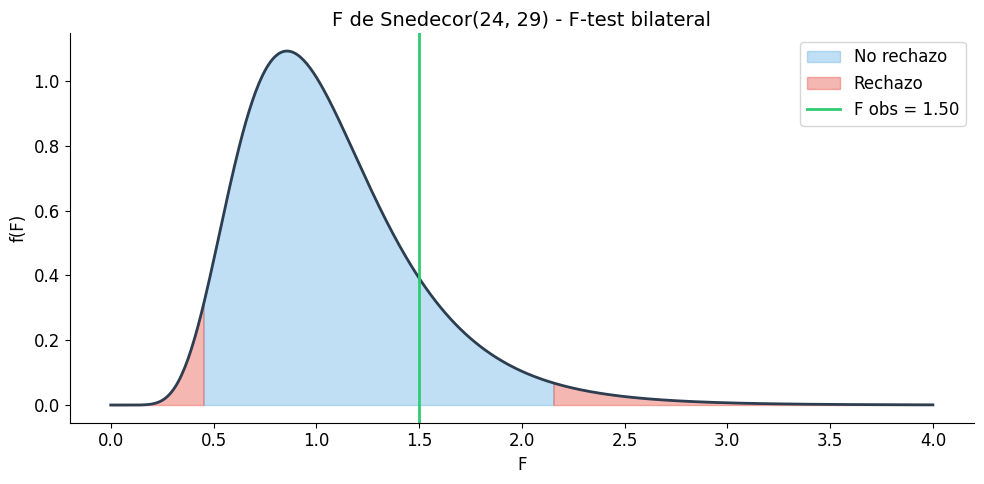

In [8]:
s1_2, n1 = 15, 25
s2_2, n2 = 10, 30
gl1, gl2 = n1 - 1, n2 - 1
alfa = 0.05

F_stat = s1_2 / s2_2
F_inf = stats.f.ppf(alfa / 2, gl1, gl2)
F_sup = stats.f.ppf(1 - alfa / 2, gl1, gl2)
p_value = 2 * min(stats.f.cdf(F_stat, gl1, gl2), 1 - stats.f.cdf(F_stat, gl1, gl2))

print(f"F = s1^2/s2^2 = {s1_2}/{s2_2} = {F_stat:.4f}")
print(f"gl1 = {gl1}, gl2 = {gl2}")
print(f"F_inf ({alfa/2}, {gl1}, {gl2}) = {F_inf:.4f}")
print(f"F_sup ({1-alfa/2}, {gl1}, {gl2}) = {F_sup:.4f}")
print(f"p-value = {p_value:.4f}")
print(f"Decision: {'Rechazar H0' if F_stat < F_inf or F_stat > F_sup else 'No rechazar H0'}")

# Grafica
x_vals = np.linspace(0, 4, 500)
F_dist = stats.f(gl1, gl2)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x_vals, F_dist.pdf(x_vals), color=C_DARK, linewidth=2)

# Region de no rechazo
x_nr = np.linspace(F_inf, F_sup, 300)
ax.fill_between(x_nr, F_dist.pdf(x_nr), alpha=0.3, color=C_PRIMARY, label='No rechazo')

# Regiones de rechazo
x_left = np.linspace(0.001, F_inf, 100)
x_right = np.linspace(F_sup, 4, 100)
ax.fill_between(x_left, F_dist.pdf(x_left), alpha=0.4, color=C_DANGER)
ax.fill_between(x_right, F_dist.pdf(x_right), alpha=0.4, color=C_DANGER, label='Rechazo')

ax.axvline(x=F_stat, color=C_SUCCESS, linewidth=2, label=f'F obs = {F_stat:.2f}')
ax.set_xlabel('F')
ax.set_ylabel('f(F)')
ax.set_title(f'F de Snedecor({gl1}, {gl2}) - F-test bilateral')
ax.legend()
plt.tight_layout()
plt.show()

**Ejercicio 8:** Para cada distribucion continua estudiada (Normal, Exponencial, t-Student, Chi-cuadrado, F de Snedecor), graficar la PDF con diferentes parametros en un grid 2x4. Construir una tabla resumen con E[X] y Var(X).

**Resolucion:**

Tabla resumen de formulas teoricas:

| Distribucion | Parametros | E[X] | Var(X) |
|---|---|---|---|
| Normal | mu, sigma | mu | sigma^2 |
| Exponencial | lambda | 1/lambda | 1/lambda^2 |
| t-Student | nu (gl) | 0 (nu>1) | nu/(nu-2) (nu>2) |
| Chi-cuadrado | nu (gl) | nu | 2*nu |
| F de Snedecor | d1, d2 | d2/(d2-2) (d2>2) | compleja |

Se graficara la PDF de cada distribucion con multiples parametros para observar como cambia su forma.

Distribucion           E[X] scipy   Var(X) scipy
--------------------------------------------------
Normal(0,1)                0.0000         1.0000
Normal(2,3)                2.0000         9.0000
Exp(scale=0.5)             0.5000         0.2500
t-Student(10)              0.0000         1.2500
Chi2(8)                    8.0000        16.0000
F(10,10)                   1.2500         0.9375


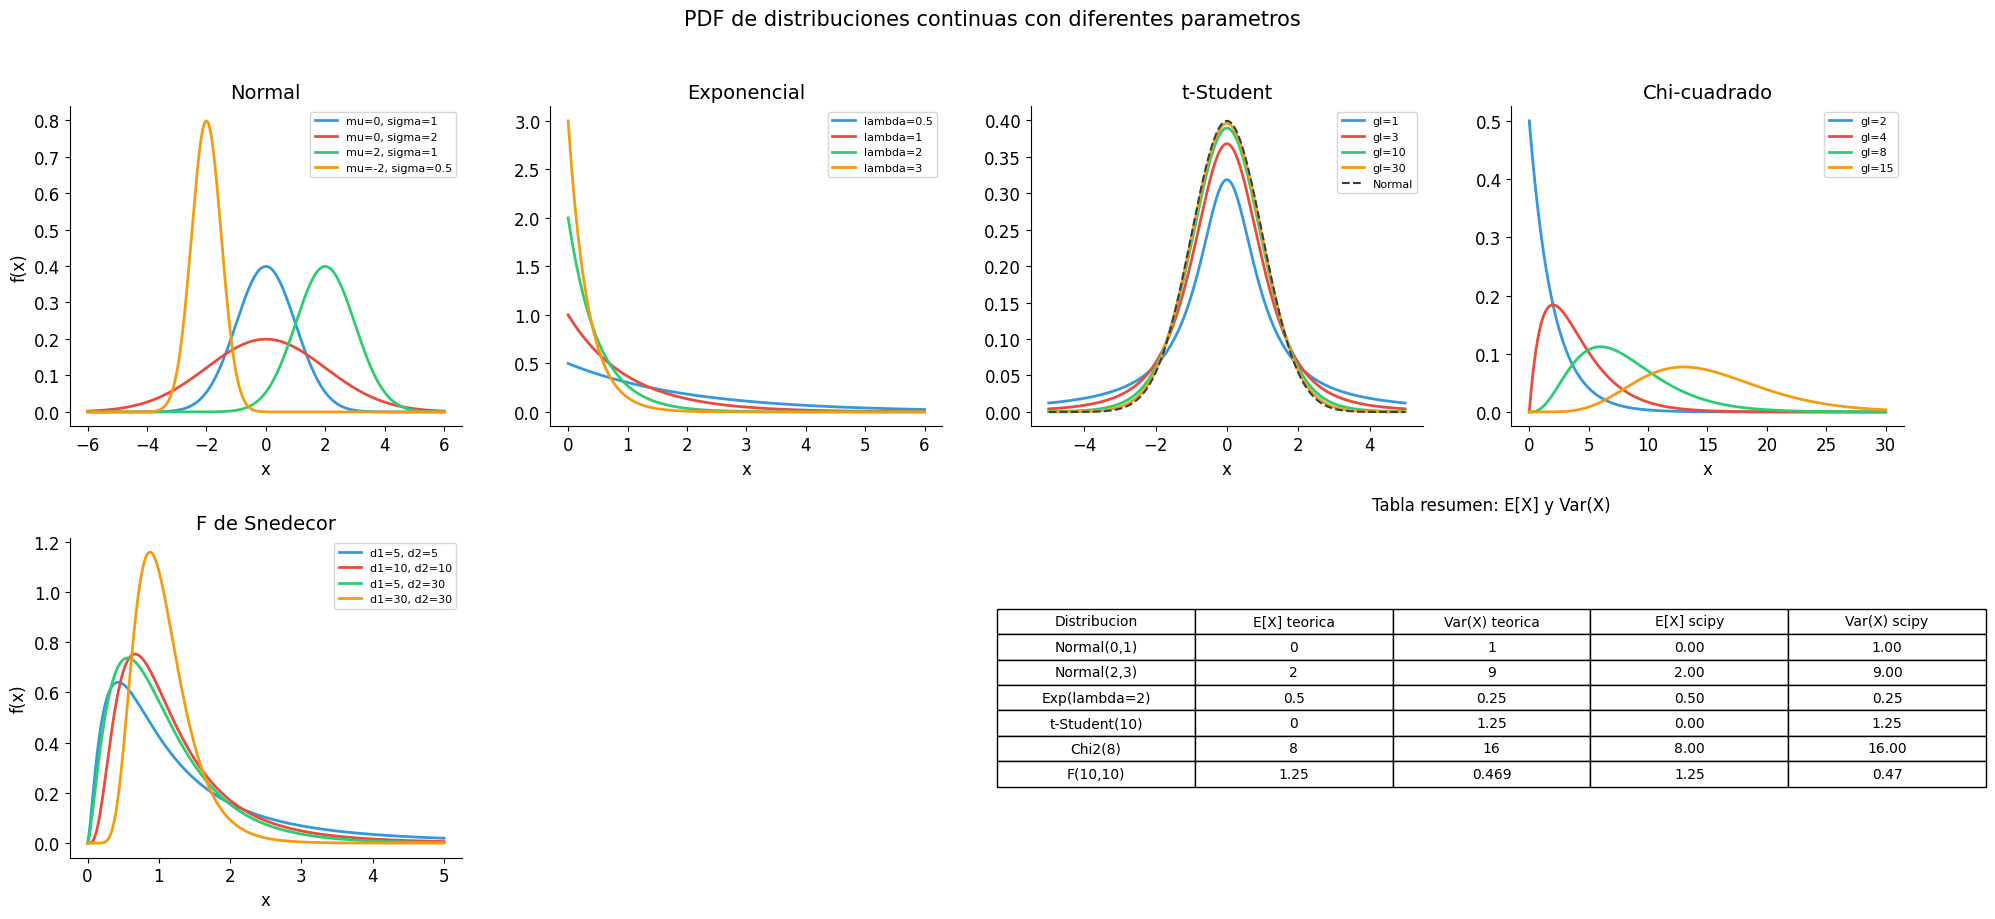

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))

colors_list = [C_PRIMARY, C_DANGER, C_SUCCESS, C_ORANGE, C_DARK]

# 1. Normal con distintas medias y sigmas
ax = axes[0, 0]
params_norm = [(0, 1), (0, 2), (2, 1), (-2, 0.5)]
x_n = np.linspace(-6, 6, 500)
for i, (mu, sig) in enumerate(params_norm):
    ax.plot(x_n, stats.norm.pdf(x_n, mu, sig), color=colors_list[i], linewidth=2,
            label=f'mu={mu}, sigma={sig}')
ax.set_title('Normal')
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.legend(fontsize=8)

# 2. Exponencial con distintos lambda
ax = axes[0, 1]
lambdas = [0.5, 1, 2, 3]
x_e = np.linspace(0, 6, 500)
for i, lam in enumerate(lambdas):
    ax.plot(x_e, stats.expon.pdf(x_e, scale=1/lam), color=colors_list[i], linewidth=2,
            label=f'lambda={lam}')
ax.set_title('Exponencial')
ax.set_xlabel('x')
ax.legend(fontsize=8)

# 3. t-Student con distintos grados de libertad
ax = axes[0, 2]
gls_t = [1, 3, 10, 30]
x_t = np.linspace(-5, 5, 500)
for i, gl in enumerate(gls_t):
    ax.plot(x_t, stats.t.pdf(x_t, gl), color=colors_list[i], linewidth=2,
            label=f'gl={gl}')
ax.plot(x_t, stats.norm.pdf(x_t), color=colors_list[4], linewidth=1.5, linestyle='--',
        label='Normal')
ax.set_title('t-Student')
ax.set_xlabel('x')
ax.legend(fontsize=8)

# 4. Chi-cuadrado con distintos gl
ax = axes[0, 3]
gls_chi = [2, 4, 8, 15]
x_c = np.linspace(0, 30, 500)
for i, gl in enumerate(gls_chi):
    ax.plot(x_c, stats.chi2.pdf(x_c, gl), color=colors_list[i], linewidth=2,
            label=f'gl={gl}')
ax.set_title('Chi-cuadrado')
ax.set_xlabel('x')
ax.legend(fontsize=8)

# 5. F de Snedecor con distintos grados de libertad
ax = axes[1, 0]
params_f = [(5, 5), (10, 10), (5, 30), (30, 30)]
x_f = np.linspace(0, 5, 500)
for i, (d1, d2) in enumerate(params_f):
    ax.plot(x_f, stats.f.pdf(x_f, d1, d2), color=colors_list[i], linewidth=2,
            label=f'd1={d1}, d2={d2}')
ax.set_title('F de Snedecor')
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.legend(fontsize=8)

# 6-8: Tabla resumen
for j in range(1, 4):
    axes[1, j].set_visible(False)

# Tabla en el espacio restante
tabla_ax = fig.add_subplot(2, 2, 4)
tabla_ax.axis('off')

tabla_data = [
    ['Normal(0,1)', '0', '1', '0.00', '1.00'],
    ['Normal(2,3)', '2', '9', '2.00', '9.00'],
    ['Exp(lambda=2)', '0.5', '0.25', '0.50', '0.25'],
    ['t-Student(10)', '0', '1.25', '0.00', '1.25'],
    ['Chi2(8)', '8', '16', '8.00', '16.00'],
    ['F(10,10)', '1.25', '0.469', '1.25', '0.47'],
]

tabla = tabla_ax.table(
    cellText=tabla_data,
    colLabels=['Distribucion', 'E[X] teorica', 'Var(X) teorica', 'E[X] scipy', 'Var(X) scipy'],
    loc='center',
    cellLoc='center',
)
tabla.auto_set_font_size(False)
tabla.set_fontsize(10)
tabla.scale(1.2, 1.5)
tabla_ax.set_title('Tabla resumen: E[X] y Var(X)', fontsize=12, pad=20)

# Verificar con scipy
print(f"{'Distribucion':<20} {'E[X] scipy':>12} {'Var(X) scipy':>14}")
print("-" * 50)
verificaciones = [
    ('Normal(0,1)', stats.norm(0, 1)),
    ('Normal(2,3)', stats.norm(2, 3)),
    ('Exp(scale=0.5)', stats.expon(scale=0.5)),
    ('t-Student(10)', stats.t(10)),
    ('Chi2(8)', stats.chi2(8)),
    ('F(10,10)', stats.f(10, 10)),
]
for nombre, dist in verificaciones:
    print(f"{nombre:<20} {dist.mean():>12.4f} {dist.var():>14.4f}")

fig.suptitle('PDF de distribuciones continuas con diferentes parametros', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

**Ejercicio 9:** El coeficiente intelectual (IQ) de una poblacion sigue una distribucion Normal con media 100 y desviacion estandar 15, es decir, $X \sim N(100, 15)$. Que porcentaje de la poblacion tiene un IQ entre 85 y 115? Y que porcentaje tiene un IQ por encima de 130?

**Resolucion:**

La variable $X$ = "IQ" sigue una distribucion **Normal** con parametros:
- $\mu = 100$ (media poblacional del IQ)
- $\sigma = 15$ (desviacion estandar)

**Parte 1: P(85 < X < 115)**

Estandarizamos con $Z = \frac{X - \mu}{\sigma}$:

$$P(85 < X < 115) = P\left(\frac{85-100}{15} < Z < \frac{115-100}{15}\right) = P(-1 < Z < 1)$$

$$= \Phi(1) - \Phi(-1) = 0.8413 - 0.1587 = 0.6827$$

Aproximadamente el **68.27%** de la poblacion tiene un IQ entre 85 y 115. Esto corresponde a una desviacion estandar alrededor de la media.

**Parte 2: P(X > 130)**

$$P(X > 130) = P\left(Z > \frac{130-100}{15}\right) = P(Z > 2) = 1 - \Phi(2) = 1 - 0.9772 = 0.0228$$

Solo el **2.28%** de la poblacion tiene un IQ superior a 130.

In [ ]:
mu, sigma = 100, 15

# Parte 1: P(85 < X < 115)
p_entre = stats.norm.cdf(115, mu, sigma) - stats.norm.cdf(85, mu, sigma)
print(f"P(85 < IQ < 115) = {p_entre:.4f} ({p_entre*100:.2f}%)")

# Parte 2: P(X > 130)
p_mayor_130 = 1 - stats.norm.cdf(130, mu, sigma)
print(f"P(IQ > 130) = {p_mayor_130:.4f} ({p_mayor_130*100:.2f}%)")

# Grafica
x = np.linspace(40, 160, 500)
y = stats.norm.pdf(x, mu, sigma)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, y, color=C_DARK, lw=2, label=f'N({mu}, {sigma})')

# Sombrear P(85 < X < 115)
mask1 = (x >= 85) & (x <= 115)
ax.fill_between(x[mask1], y[mask1], alpha=0.3, color=C_PRIMARY, label=f'P(85 < IQ < 115) = {p_entre:.4f}')

# Sombrear P(X > 130)
mask2 = x >= 130
ax.fill_between(x[mask2], y[mask2], alpha=0.3, color=C_DANGER, label=f'P(IQ > 130) = {p_mayor_130:.4f}')

ax.set_xlabel('IQ')
ax.set_ylabel('Densidad')
ax.set_title('Distribucion del IQ - N(100, 15)')
ax.legend()
plt.tight_layout()
plt.show()

**Ejercicio 10:** El tiempo entre llamadas en un centro de atencion sigue una distribucion Exponencial con tasa $\lambda = 3$ llamadas por minuto, es decir, $X \sim \text{Exp}(\lambda=3)$. Cual es la probabilidad de esperar mas de 1 minuto entre dos llamadas consecutivas?

**Resolucion:**

La variable $X$ = "tiempo entre llamadas" sigue una distribucion **Exponencial** con parametros:
- $\lambda = 3$: tasa de llegada (3 llamadas por minuto en promedio)
- $E[X] = 1/\lambda = 1/3$ minuto (20 segundos de espera media)

**Formula de la funcion de supervivencia:**

$$P(X > t) = e^{-\lambda t}$$

**Calculo:**

$$P(X > 1) = e^{-3 \cdot 1} = e^{-3} \approx 0.0498$$

La probabilidad de esperar mas de 1 minuto es de aproximadamente **4.98%**. Dado que la tasa es de 3 llamadas por minuto, es poco probable que pase un minuto entero sin recibir ninguna llamada.

In [ ]:
lam = 3  # tasa: 3 llamadas por minuto

# P(X > 1) usando la funcion de supervivencia
p_mayor_1 = 1 - stats.expon.cdf(1, scale=1/lam)
print(f"P(X > 1 min) = {p_mayor_1:.4f} ({p_mayor_1*100:.2f}%)")
print(f"Verificacion analitica: e^(-3) = {np.exp(-3):.4f}")
print(f"Tiempo medio entre llamadas: {1/lam:.4f} min = {1/lam*60:.1f} seg")

# Grafica
x = np.linspace(0, 2.5, 500)
y = stats.expon.pdf(x, scale=1/lam)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, y, color=C_DARK, lw=2, label=f'Exp(lambda={lam})')

# Sombrear P(X > 1)
mask = x >= 1
ax.fill_between(x[mask], y[mask], alpha=0.3, color=C_DANGER, label=f'P(X > 1) = {p_mayor_1:.4f}')

ax.axvline(1, color=C_ORANGE, ls='--', lw=1.5, label='t = 1 min')
ax.set_xlabel('Tiempo entre llamadas (min)')
ax.set_ylabel('Densidad')
ax.set_title('Distribucion Exponencial - Exp(lambda=3)')
ax.legend()
plt.tight_layout()
plt.show()

**Ejercicio 11:** El tiempo necesario para que ocurran 5 eventos, donde cada evento ocurre con una tasa de 2 por hora, sigue una distribucion Gamma con parametros $\alpha=5$ (forma) y $\beta=2$ (tasa), es decir, $T \sim \text{Gamma}(5, 2)$. Calcular la esperanza $E[T]$ y la probabilidad $P(T > 4)$.

**Resolucion:**

La variable $T$ = "tiempo hasta el 5to evento" sigue una distribucion **Gamma** con parametros:
- $\alpha = 5$: parametro de forma (numero de eventos que esperamos)
- $\beta = 2$: parametro de tasa (eventos por hora)
- En scipy, se usa `scale = 1/beta` para la parametrizacion

**Esperanza:**

$$E[T] = \frac{\alpha}{\beta} = \frac{5}{2} = 2.5 \text{ horas}$$

**Varianza:**

$$\text{Var}(T) = \frac{\alpha}{\beta^2} = \frac{5}{4} = 1.25$$

**Calculo de P(T > 4):**

$$P(T > 4) = 1 - F_{\text{Gamma}}(4; \alpha=5, \beta=2)$$

donde $F_{\text{Gamma}}$ es la funcion de distribucion acumulada (CDF) de la Gamma. Este valor se calcula numericamente.

In [ ]:
alpha, beta_rate = 5, 2

# En scipy: Gamma(a=alpha, scale=1/beta)
dist = stats.gamma(a=alpha, scale=1/beta_rate)

E_T = dist.mean()
Var_T = dist.var()
p_mayor_4 = 1 - dist.cdf(4)

print(f"E[T] = alpha/beta = {alpha}/{beta_rate} = {E_T:.4f} horas")
print(f"Var(T) = alpha/beta^2 = {alpha}/{beta_rate**2} = {Var_T:.4f}")
print(f"P(T > 4) = {p_mayor_4:.4f} ({p_mayor_4*100:.2f}%)")

# Grafica
x = np.linspace(0, 7, 500)
y = dist.pdf(x)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, y, color=C_DARK, lw=2, label=f'Gamma(alpha={alpha}, beta={beta_rate})')

mask = x >= 4
ax.fill_between(x[mask], y[mask], alpha=0.3, color=C_DANGER, label=f'P(T > 4) = {p_mayor_4:.4f}')
ax.axvline(E_T, color=C_SUCCESS, ls='--', lw=1.5, label=f'E[T] = {E_T:.2f}')

ax.set_xlabel('Tiempo (horas)')
ax.set_ylabel('Densidad')
ax.set_title('Distribucion Gamma(5, 2) - Tiempo hasta el 5to evento')
ax.legend()
plt.tight_layout()
plt.show()

**Ejercicio 12:** La proporcion de exitos en un experimento sigue una distribucion Beta con parametros $\alpha=2$ y $\beta=5$, es decir, $X \sim \text{Beta}(2, 5)$. Calcular la esperanza $E[X]$, la moda, y graficar la distribucion.

**Resolucion:**

La variable $X$ = "proporcion de exitos" sigue una distribucion **Beta** con parametros:
- $\alpha = 2$: parametro de forma asociado a exitos
- $\beta = 5$: parametro de forma asociado a fracasos
- El dominio de la Beta es $[0, 1]$, ideal para modelar proporciones

**Esperanza:**

$$E[X] = \frac{\alpha}{\alpha + \beta} = \frac{2}{2 + 5} = \frac{2}{7} \approx 0.2857$$

**Moda** (el valor mas probable, existe cuando $\alpha > 1$ y $\beta > 1$):

$$\text{Moda} = \frac{\alpha - 1}{\alpha + \beta - 2} = \frac{2 - 1}{2 + 5 - 2} = \frac{1}{5} = 0.20$$

**Varianza:**

$$\text{Var}(X) = \frac{\alpha\beta}{(\alpha+\beta)^2(\alpha+\beta+1)} = \frac{2 \cdot 5}{49 \cdot 8} = \frac{10}{392} \approx 0.0255$$

La distribucion esta sesgada hacia la izquierda, lo que indica que la proporcion de exitos tiende a ser baja.

In [ ]:
a, b = 2, 5

dist = stats.beta(a, b)

E_X = dist.mean()
Var_X = dist.var()
moda = (a - 1) / (a + b - 2)

print(f"E[X] = {a}/({a}+{b}) = {E_X:.4f}")
print(f"Moda = ({a}-1)/({a}+{b}-2) = {moda:.4f}")
print(f"Var(X) = {Var_X:.4f}")

# Grafica
x = np.linspace(0, 1, 500)
y = dist.pdf(x)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, y, color=C_DARK, lw=2, label=f'Beta({a}, {b})')
ax.fill_between(x, y, alpha=0.2, color=C_PRIMARY)

ax.axvline(E_X, color=C_SUCCESS, ls='--', lw=1.5, label=f'E[X] = {E_X:.4f}')
ax.axvline(moda, color=C_ORANGE, ls='--', lw=1.5, label=f'Moda = {moda:.4f}')

ax.set_xlabel('Proporcion de exitos')
ax.set_ylabel('Densidad')
ax.set_title('Distribucion Beta(2, 5)')
ax.legend()
plt.tight_layout()
plt.show()

**Ejercicio 13:** La suma de los cuadrados de 10 variables normales estandar independientes sigue una distribucion Chi-cuadrado con 10 grados de libertad, es decir, $Y = \sum_{i=1}^{10} Z_i^2 \sim \chi^2(10)$ donde cada $Z_i \sim N(0,1)$. Calcular $P(\chi^2 > 18.31)$.

**Resolucion:**

La variable $Y$ sigue una distribucion **Chi-cuadrado** con parametros:
- $k = 10$: grados de libertad (numero de normales estandar al cuadrado que se suman)
- $Z_i \sim N(0,1)$: cada variable normal estandar independiente
- $Y = Z_1^2 + Z_2^2 + \ldots + Z_{10}^2$

**Propiedades:**
- $E[Y] = k = 10$
- $\text{Var}(Y) = 2k = 20$

**Calculo de P(Y > 18.31):**

$$P(\chi^2_{10} > 18.31) = 1 - F_{\chi^2}(18.31; k=10)$$

El valor 18.31 corresponde aproximadamente al valor critico para un nivel de significancia de 0.05 en la tabla Chi-cuadrado con 10 gl. Se calcula numericamente.

In [ ]:
k = 10  # grados de libertad
valor = 18.31

dist = stats.chi2(df=k)

p_mayor = 1 - dist.cdf(valor)
print(f"P(chi2_10 > {valor}) = {p_mayor:.4f} ({p_mayor*100:.2f}%)")
print(f"E[Y] = {dist.mean():.1f}")
print(f"Var(Y) = {dist.var():.1f}")

# Verificacion por simulacion
np.random.seed(42)
n_sim = 100_000
sumas = np.sum(np.random.standard_normal((n_sim, k))**2, axis=1)
p_sim = np.mean(sumas > valor)
print(f"Verificacion por simulacion: P(chi2 > {valor}) = {p_sim:.4f}")

# Grafica
x = np.linspace(0, 30, 500)
y = dist.pdf(x)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, y, color=C_DARK, lw=2, label=f'Chi2(k={k})')

mask = x >= valor
ax.fill_between(x[mask], y[mask], alpha=0.3, color=C_DANGER, label=f'P(chi2 > {valor}) = {p_mayor:.4f}')
ax.axvline(valor, color=C_ORANGE, ls='--', lw=1.5, label=f'x = {valor}')

ax.set_xlabel('Valor')
ax.set_ylabel('Densidad')
ax.set_title('Distribucion Chi-cuadrado con 10 gl')
ax.legend()
plt.tight_layout()
plt.show()

**Ejercicio 14:** Se tiene una muestra de $n=8$ observaciones con media muestral $\bar{x}=25$ y desviacion estandar muestral $s=4$. Bajo el supuesto de normalidad, el estadistico $t = \frac{\bar{x} - \mu_0}{s/\sqrt{n}}$ sigue una distribucion t-Student con $\nu = n-1 = 7$ grados de libertad. Calcular la probabilidad de que $t > 2.0$.

**Resolucion:**

El estadistico $t$ sigue una distribucion **t-Student** con parametros:
- $\nu = 7$: grados de libertad ($n - 1 = 8 - 1$)
- $n = 8$: tamano de la muestra
- $\bar{x} = 25$: media muestral
- $s = 4$: desviacion estandar muestral

**El estadistico t-Student:**

$$t = \frac{\bar{x} - \mu_0}{s / \sqrt{n}}$$

donde $\mu_0$ es el valor hipotetico de la media poblacional. El estadistico $t$ compensa la incertidumbre adicional de estimar $\sigma$ con $s$, usando colas mas pesadas que la Normal.

**Calculo de P(t > 2.0):**

$$P(t_7 > 2.0) = 1 - F_{t}(2.0; \nu=7)$$

Con 7 grados de libertad, la distribucion t tiene colas mas pesadas que la Normal estandar, por lo que $P(t > 2.0)$ sera mayor que $P(Z > 2.0)$.

In [ ]:
n, x_bar, s = 8, 25, 4
nu = n - 1  # grados de libertad
t_valor = 2.0

dist = stats.t(df=nu)

p_mayor = 1 - dist.cdf(t_valor)
p_normal = 1 - stats.norm.cdf(t_valor)

print(f"P(t_7 > {t_valor}) = {p_mayor:.4f} ({p_mayor*100:.2f}%)")
print(f"Comparacion con Normal: P(Z > {t_valor}) = {p_normal:.4f} ({p_normal*100:.2f}%)")
print(f"La t-Student asigna mas probabilidad a las colas que la Normal")

# Grafica comparativa
x = np.linspace(-5, 5, 500)
y_t = dist.pdf(x)
y_norm = stats.norm.pdf(x)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, y_t, color=C_PRIMARY, lw=2, label=f't-Student(nu={nu})')
ax.plot(x, y_norm, color=C_DARK, lw=2, ls='--', label='Normal(0,1)')

mask = x >= t_valor
ax.fill_between(x[mask], y_t[mask], alpha=0.3, color=C_DANGER, label=f'P(t > {t_valor}) = {p_mayor:.4f}')

ax.axvline(t_valor, color=C_ORANGE, ls='--', lw=1.5, label=f't = {t_valor}')
ax.set_xlabel('Valor del estadistico')
ax.set_ylabel('Densidad')
ax.set_title(f't-Student(nu={nu}) vs Normal estandar')
ax.legend()
plt.tight_layout()
plt.show()

**Ejercicio 15:** Los salarios anuales de una empresa siguen una distribucion Log-normal con parametros $\mu=10$ y $\sigma=0.5$, es decir, $X \sim \text{LogN}(10, 0.5)$, donde $\mu$ y $\sigma$ son la media y desviacion estandar del logaritmo natural de los salarios. Calcular la mediana, la media, y la probabilidad de que un salario supere los 30000.

**Resolucion:**

La variable $X$ = "salario anual" sigue una distribucion **Log-normal** con parametros:
- $\mu = 10$: media del logaritmo natural de $X$ (no es la media de $X$)
- $\sigma = 0.5$: desviacion estandar del logaritmo natural de $X$
- Si $\ln(X) \sim N(\mu, \sigma)$, entonces $X \sim \text{LogN}(\mu, \sigma)$

**Mediana:**

$$\text{Mediana} = e^{\mu} = e^{10} \approx 22026.47$$

La mediana de la Log-normal es simplemente $e^\mu$, ya que la mediana de $\ln(X)$ es $\mu$ y la exponencial es una transformacion monotona.

**Media (esperanza):**

$$E[X] = e^{\mu + \sigma^2/2} = e^{10 + 0.25/2} = e^{10.125} \approx 24946.79$$

Notar que la media es mayor que la mediana, lo cual refleja el sesgo positivo tipico de la Log-normal.

**P(X > 30000):**

$$P(X > 30000) = P(\ln X > \ln 30000) = P\left(Z > \frac{\ln 30000 - \mu}{\sigma}\right)$$

$$= P\left(Z > \frac{10.3090 - 10}{0.5}\right) = P(Z > 0.618)$$

In [ ]:
mu_ln, sigma_ln = 10, 0.5

# En scipy: lognorm(s=sigma, scale=exp(mu))
dist = stats.lognorm(s=sigma_ln, scale=np.exp(mu_ln))

mediana = np.exp(mu_ln)
media = dist.mean()
p_mayor_30k = 1 - dist.cdf(30000)

print(f"Mediana = e^mu = e^{mu_ln} = {mediana:.2f}")
print(f"Media = e^(mu + sigma^2/2) = e^{mu_ln + sigma_ln**2/2:.3f} = {media:.2f}")
print(f"P(Salario > 30000) = {p_mayor_30k:.4f} ({p_mayor_30k*100:.2f}%)")
print(f"\nNotar: Media ({media:.2f}) > Mediana ({mediana:.2f}) -> sesgo positivo")

# Grafica
x = np.linspace(0, 80000, 1000)
y = dist.pdf(x)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, y, color=C_DARK, lw=2, label=f'LogN(mu={mu_ln}, sigma={sigma_ln})')

mask = x >= 30000
ax.fill_between(x[mask], y[mask], alpha=0.3, color=C_DANGER, label=f'P(X > 30000) = {p_mayor_30k:.4f}')

ax.axvline(mediana, color=C_SUCCESS, ls='--', lw=1.5, label=f'Mediana = {mediana:.0f}')
ax.axvline(media, color=C_ORANGE, ls='--', lw=1.5, label=f'Media = {media:.0f}')

ax.set_xlabel('Salario anual')
ax.set_ylabel('Densidad')
ax.set_title('Distribucion Log-normal de salarios')
ax.legend()
plt.tight_layout()
plt.show()

**Ejercicio 16:** El tiempo de espera de un autobus sigue una distribucion Uniforme continua entre 0 y 10 minutos, es decir, $X \sim U(0, 10)$. Calcular la probabilidad de esperar entre 3 y 7 minutos, y la esperanza $E[X]$.

**Resolucion:**

La variable $X$ = "tiempo de espera" sigue una distribucion **Uniforme continua** con parametros:
- $a = 0$: limite inferior del intervalo
- $b = 10$: limite superior del intervalo
- La densidad es constante: $f(x) = \frac{1}{b-a} = \frac{1}{10} = 0.1$ para $x \in [0, 10]$

**Esperanza:**

$$E[X] = \frac{a + b}{2} = \frac{0 + 10}{2} = 5 \text{ minutos}$$

**Varianza:**

$$\text{Var}(X) = \frac{(b - a)^2}{12} = \frac{100}{12} \approx 8.33$$

**P(3 < X < 7):**

Para la Uniforme, la probabilidad es simplemente la proporcion del intervalo:

$$P(3 < X < 7) = \frac{7 - 3}{b - a} = \frac{4}{10} = 0.40$$

El **40%** del tiempo se espera entre 3 y 7 minutos.

In [ ]:
a, b = 0, 10

dist = stats.uniform(loc=a, scale=b - a)

E_X = dist.mean()
Var_X = dist.var()
p_entre = dist.cdf(7) - dist.cdf(3)

print(f"E[X] = (a+b)/2 = ({a}+{b})/2 = {E_X:.2f} minutos")
print(f"Var(X) = (b-a)^2/12 = {(b-a)**2}/12 = {Var_X:.4f}")
print(f"P(3 < X < 7) = (7-3)/(b-a) = 4/{b-a} = {p_entre:.4f} ({p_entre*100:.1f}%)")

# Grafica
x = np.linspace(-1, 11, 500)
y = dist.pdf(x)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, y, color=C_DARK, lw=2, label=f'U({a}, {b})')

mask = (x >= 3) & (x <= 7)
ax.fill_between(x[mask], y[mask], alpha=0.3, color=C_PRIMARY, label=f'P(3 < X < 7) = {p_entre:.2f}')

ax.axvline(E_X, color=C_SUCCESS, ls='--', lw=1.5, label=f'E[X] = {E_X:.1f}')
ax.set_xlabel('Tiempo de espera (min)')
ax.set_ylabel('Densidad')
ax.set_title('Distribucion Uniforme continua U(0, 10)')
ax.legend()
ax.set_ylim(-0.02, 0.15)
plt.tight_layout()
plt.show()

**Ejercicio 17:** La regla 68-95-99.7 establece que para una distribucion Normal, aproximadamente el 68% de los datos caen dentro de 1 desviacion estandar de la media, el 95% dentro de 2, y el 99.7% dentro de 3. Verificar esta regla mediante simulacion de 100000 muestras de $Z \sim N(0,1)$.

**Resolucion:**

La regla **68-95-99.7** (tambien llamada regla empirica) aplica a cualquier distribucion Normal $X \sim N(\mu, \sigma)$:

- $P(\mu - 1\sigma < X < \mu + 1\sigma) \approx 0.6827$ (68%)
- $P(\mu - 2\sigma < X < \mu + 2\sigma) \approx 0.9545$ (95%)
- $P(\mu - 3\sigma < X < \mu + 3\sigma) \approx 0.9973$ (99.7%)

**Simbolos:**
- $\mu$: media de la distribucion
- $\sigma$: desviacion estandar
- $k\sigma$: $k$ desviaciones estandar respecto a la media

**Valores teoricos exactos:**

$$P(-k < Z < k) = 2\Phi(k) - 1$$

donde $\Phi$ es la CDF de la Normal estandar y $Z \sim N(0,1)$. Verificaremos comparando los valores teoricos con los obtenidos por simulacion de Monte Carlo.

In [ ]:
np.random.seed(42)
n_sim = 100_000
muestras = np.random.standard_normal(n_sim)

print("Regla 68-95-99.7: Verificacion por simulacion")
print(f"{'k sigma':<10} {'Teorico':<12} {'Simulado':<12} {'Regla':<10}")
print("-" * 44)

for k, regla in [(1, "68%"), (2, "95%"), (3, "99.7%")]:
    teorico = stats.norm.cdf(k) - stats.norm.cdf(-k)
    simulado = np.mean(np.abs(muestras) < k)
    print(f"{k} sigma    {teorico:.4f}       {simulado:.4f}       {regla}")

# Grafica
x = np.linspace(-4, 4, 500)
y = stats.norm.pdf(x)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(x, y, color=C_DARK, lw=2)

colores = [C_PRIMARY, C_SUCCESS, C_ORANGE]
alphas = [0.4, 0.25, 0.15]
for k, color, alpha_val, pct in zip([1, 2, 3], colores, alphas, ['68%', '95%', '99.7%']):
    mask = (x >= -k) & (x <= k)
    ax.fill_between(x[mask], y[mask], alpha=alpha_val, color=color, label=f'{k} sigma: {pct}')

ax.set_xlabel('Desviaciones estandar')
ax.set_ylabel('Densidad')
ax.set_title('Regla 68-95-99.7 de la distribucion Normal')
ax.legend()
plt.tight_layout()
plt.show()

**Ejercicio 18:** La distribucion Exponencial tiene la propiedad de falta de memoria (memoryless): $P(X > s + t \mid X > s) = P(X > t)$. Demostrar esta propiedad mediante calculo analitico y verificarla con una simulacion para $X \sim \text{Exp}(\lambda=2)$, con $s=1$ y $t=0.5$.

**Resolucion:**

La propiedad de **falta de memoria** establece que:

$$P(X > s + t \mid X > s) = P(X > t)$$

**Simbolos:**
- $X \sim \text{Exp}(\lambda)$: variable exponencial con tasa $\lambda$
- $s$: tiempo ya transcurrido sin que ocurra el evento
- $t$: tiempo adicional de espera
- $P(A \mid B)$: probabilidad condicional de $A$ dado $B$

**Demostracion analitica:**

Usando la definicion de probabilidad condicional y la funcion de supervivencia $P(X > x) = e^{-\lambda x}$:

$$P(X > s + t \mid X > s) = \frac{P(X > s + t \cap X > s)}{P(X > s)} = \frac{P(X > s + t)}{P(X > s)}$$

$$= \frac{e^{-\lambda(s+t)}}{e^{-\lambda s}} = \frac{e^{-\lambda s} \cdot e^{-\lambda t}}{e^{-\lambda s}} = e^{-\lambda t} = P(X > t)$$

Esto significa que la Exponencial "no recuerda" cuanto tiempo ha pasado. La probabilidad de esperar $t$ minutos mas es la misma, sin importar cuanto se haya esperado ya.

In [ ]:
lam = 2
s, t = 1, 0.5

# Calculo analitico
p_condicional = np.exp(-lam * t)
p_directo = np.exp(-lam * t)
p_st = np.exp(-lam * (s + t))
p_s = np.exp(-lam * s)

print("Demostracion analitica:")
print(f"P(X > s+t | X > s) = P(X > {s+t}) / P(X > {s}) = {p_st:.6f} / {p_s:.6f} = {p_st/p_s:.6f}")
print(f"P(X > t) = P(X > {t}) = {p_directo:.6f}")
print(f"Son iguales: {np.isclose(p_st/p_s, p_directo)}")

# Verificacion por simulacion
np.random.seed(42)
n_sim = 100_000
muestras = np.random.exponential(scale=1/lam, size=n_sim)

# P(X > s+t | X > s) estimada: de las muestras que superan s, que fraccion supera s+t
superan_s = muestras[muestras > s]
p_cond_sim = np.mean(superan_s > s + t)

# P(X > t) estimada
p_t_sim = np.mean(muestras > t)

print(f"\nVerificacion por simulacion ({n_sim} muestras):")
print(f"P(X > {s+t} | X > {s}) simulada = {p_cond_sim:.4f}")
print(f"P(X > {t}) simulada = {p_t_sim:.4f}")
print(f"Valor teorico = {p_condicional:.4f}")
print(f"La propiedad sin memoria se verifica: ambas probabilidades coinciden")

**Ejercicio 19:** La distribucion F de Snedecor se define como el cociente de dos variables Chi-cuadrado independientes, cada una dividida por sus grados de libertad. Si $U \sim \chi^2(d_1)$ y $V \sim \chi^2(d_2)$ son independientes, entonces $F = \frac{U/d_1}{V/d_2} \sim F(d_1, d_2)$. Simular este cociente con $d_1=5$ y $d_2=10$, y comparar el histograma con la densidad F teorica.

**Resolucion:**

La distribucion **F de Snedecor** surge como cociente de dos Chi-cuadrado independientes normalizadas por sus grados de libertad:

$$F = \frac{U / d_1}{V / d_2} \sim F(d_1, d_2)$$

**Simbolos:**
- $U \sim \chi^2(d_1)$: variable Chi-cuadrado con $d_1$ grados de libertad (numerador)
- $V \sim \chi^2(d_2)$: variable Chi-cuadrado con $d_2$ grados de libertad (denominador)
- $d_1 = 5$: grados de libertad del numerador
- $d_2 = 10$: grados de libertad del denominador
- $U$ y $V$ son independientes entre si

**Propiedades con $d_1=5$, $d_2=10$:**
- $E[F] = \frac{d_2}{d_2 - 2} = \frac{10}{8} = 1.25$ (para $d_2 > 2$)
- $\text{Var}(F) = \frac{2 d_2^2 (d_1 + d_2 - 2)}{d_1 (d_2-2)^2 (d_2-4)} = \frac{2 \cdot 100 \cdot 13}{5 \cdot 64 \cdot 6} \approx 1.354$

La simulacion construye la F directamente desde su definicion, generando Chi-cuadrados y calculando el cociente.

In [ ]:
d1, d2 = 5, 10

np.random.seed(42)
n_sim = 100_000

# Simular desde la definicion: F = (U/d1) / (V/d2)
U = np.random.chisquare(df=d1, size=n_sim)
V = np.random.chisquare(df=d2, size=n_sim)
F_sim = (U / d1) / (V / d2)

# Distribucion teorica
dist_f = stats.f(dfn=d1, dfd=d2)

print(f"Distribucion F({d1}, {d2})")
print(f"{'':15} {'Teorico':>10} {'Simulado':>10}")
print(f"{'Media':<15} {dist_f.mean():>10.4f} {np.mean(F_sim):>10.4f}")
print(f"{'Varianza':<15} {dist_f.var():>10.4f} {np.var(F_sim):>10.4f}")

# Grafica: histograma de simulacion vs densidad teorica
x = np.linspace(0, 6, 500)
y = dist_f.pdf(x)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(F_sim, bins=100, density=True, alpha=0.4, color=C_PRIMARY, label='Simulacion (cociente de Chi2)')
ax.plot(x, y, color=C_DANGER, lw=2, label=f'F({d1}, {d2}) teorica')

ax.axvline(dist_f.mean(), color=C_SUCCESS, ls='--', lw=1.5, label=f'E[F] = {dist_f.mean():.2f}')
ax.set_xlabel('Valor de F')
ax.set_ylabel('Densidad')
ax.set_title(f'F de Snedecor: simulacion desde Chi2 vs distribucion teorica')
ax.set_xlim(0, 6)
ax.legend()
plt.tight_layout()
plt.show()

**Ejercicio 20:** Crear una galeria visual que muestre las 9 distribuciones continuas estudiadas (Normal, Exponencial, Gamma, Beta, t-Student, Chi-cuadrado, F de Snedecor, Uniforme continua, Log-normal) en un grid 3x3, cada una con diferentes combinaciones de parametros para observar como cambian sus formas.

**Resolucion:**

Se grafican las 9 distribuciones continuas con multiples parametros para visualizar como cambia la forma de cada una:

1. **Normal** $N(\mu, \sigma)$: variando media y desviacion estandar
2. **Exponencial** $\text{Exp}(\lambda)$: variando la tasa
3. **Gamma** $\text{Gamma}(\alpha, \beta)$: variando forma y tasa
4. **Beta** $\text{Beta}(\alpha, \beta)$: variando ambos parametros de forma
5. **t-Student** $t(\nu)$: variando grados de libertad
6. **Chi-cuadrado** $\chi^2(k)$: variando grados de libertad
7. **F de Snedecor** $F(d_1, d_2)$: variando grados de libertad del numerador y denominador
8. **Uniforme** $U(a, b)$: variando los limites del intervalo
9. **Log-normal** $\text{LogN}(\mu, \sigma)$: variando media y desviacion estandar del logaritmo

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
colores = [C_PRIMARY, C_DANGER, C_SUCCESS, C_ORANGE, C_DARK]

# 1. Normal
ax = axes[0, 0]
for i, (mu, sigma) in enumerate([(0, 1), (0, 2), (2, 1), (-2, 0.5)]):
    x = np.linspace(-6, 6, 500)
    ax.plot(x, stats.norm.pdf(x, mu, sigma), color=colores[i], lw=2, label=f'N({mu}, {sigma})')
ax.set_title('Normal')
ax.legend(fontsize=8)

# 2. Exponencial
ax = axes[0, 1]
for i, lam in enumerate([0.5, 1, 2, 5]):
    x = np.linspace(0, 6, 500)
    ax.plot(x, stats.expon.pdf(x, scale=1/lam), color=colores[i], lw=2, label=f'Exp({lam})')
ax.set_title('Exponencial')
ax.legend(fontsize=8)

# 3. Gamma
ax = axes[0, 2]
for i, (a, b) in enumerate([(1, 1), (2, 1), (5, 1), (5, 2)]):
    x = np.linspace(0, 12, 500)
    ax.plot(x, stats.gamma.pdf(x, a, scale=1/b), color=colores[i], lw=2, label=f'Gamma({a}, {b})')
ax.set_title('Gamma')
ax.legend(fontsize=8)

# 4. Beta
ax = axes[1, 0]
for i, (a, b) in enumerate([(0.5, 0.5), (1, 1), (2, 5), (5, 2), (2, 2)]):
    x = np.linspace(0.01, 0.99, 500)
    ax.plot(x, stats.beta.pdf(x, a, b), color=colores[i], lw=2, label=f'Beta({a}, {b})')
ax.set_title('Beta')
ax.legend(fontsize=8)

# 5. t-Student
ax = axes[1, 1]
for i, nu in enumerate([1, 3, 10, 30]):
    x = np.linspace(-5, 5, 500)
    ax.plot(x, stats.t.pdf(x, df=nu), color=colores[i], lw=2, label=f't({nu})')
ax.plot(x, stats.norm.pdf(x), color=colores[4], lw=2, ls='--', label='N(0,1)')
ax.set_title('t-Student')
ax.legend(fontsize=8)

# 6. Chi-cuadrado
ax = axes[1, 2]
for i, k in enumerate([2, 4, 7, 10]):
    x = np.linspace(0, 25, 500)
    ax.plot(x, stats.chi2.pdf(x, df=k), color=colores[i], lw=2, label=f'Chi2({k})')
ax.set_title('Chi-cuadrado')
ax.legend(fontsize=8)

# 7. F de Snedecor
ax = axes[2, 0]
for i, (d1, d2) in enumerate([(2, 5), (5, 10), (10, 20), (20, 50)]):
    x = np.linspace(0.01, 5, 500)
    ax.plot(x, stats.f.pdf(x, dfn=d1, dfd=d2), color=colores[i], lw=2, label=f'F({d1}, {d2})')
ax.set_title('F de Snedecor')
ax.legend(fontsize=8)

# 8. Uniforme continua
ax = axes[2, 1]
for i, (a, b) in enumerate([(0, 1), (0, 5), (2, 4), (-1, 3)]):
    x = np.linspace(-2, 6, 500)
    ax.plot(x, stats.uniform.pdf(x, loc=a, scale=b-a), color=colores[i], lw=2, label=f'U({a}, {b})')
ax.set_title('Uniforme continua')
ax.legend(fontsize=8)
ax.set_ylim(-0.05, 1.2)

# 9. Log-normal
ax = axes[2, 2]
for i, (mu, sigma) in enumerate([(0, 0.25), (0, 0.5), (0, 1), (1, 0.5)]):
    x = np.linspace(0.01, 8, 500)
    ax.plot(x, stats.lognorm.pdf(x, s=sigma, scale=np.exp(mu)), color=colores[i], lw=2, label=f'LogN({mu}, {sigma})')
ax.set_title('Log-normal')
ax.legend(fontsize=8)

for ax in axes.flat:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Galeria de distribuciones continuas', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()